In [11]:
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv(r'C:\Users\Rodrigo Lapsky\Documents\Dados\DataSets\Pizza\pizza_sales.csv')

In [4]:
print(df.shape)
df.head(15)

(48620, 12)


,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1.0,1.0,hawaiian_m,1.0,1/1/2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2.0,2.0,classic_dlx_m,1.0,1/1/2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3.0,2.0,five_cheese_l,1.0,1/1/2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4.0,2.0,ital_supr_l,1.0,1/1/2015,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5.0,2.0,mexicana_m,1.0,1/1/2015,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza
5,6.0,2.0,thai_ckn_l,1.0,1/1/2015,11:57:40,20.75,20.75,L,Chicken,"Chicken, Pineapple, Tomatoes, Red Peppers, Tha...",The Thai Chicken Pizza
6,7.0,3.0,ital_supr_m,1.0,1/1/2015,12:12:28,16.50,16.50,M,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
7,8.0,3.0,prsc_argla_l,1.0,1/1/2015,12:12:28,20.75,20.75,L,Supreme,"Prosciutto di San Daniele, Arugula, Mozzarella...",The Prosciutto and Arugula Pizza
8,9.0,4.0,ital_supr_m,1.0,1/1/2015,12:16:31,16.50,16.50,M,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
9,10.0,5.0,ital_supr_m,1.0,1/1/2015,12:21:30,16.50,16.50,M,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza


In [5]:
print(df.duplicated().sum())
print(df.isnull().sum())

0
pizza_id             0
order_id             0
pizza_name_id        0
quantity             0
order_date           0
order_time           0
unit_price           0
total_price          0
pizza_size           0
pizza_category       0
pizza_ingredients    0
pizza_name           0
dtype: int64


In [6]:
df = df.drop(columns=['pizza_id','pizza_name_id','order_id'])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   quantity           48620 non-null  float64
 1   order_date         48620 non-null  object 
 2   order_time         48620 non-null  object 
 3   unit_price         48620 non-null  float64
 4   total_price        48620 non-null  float64
 5   pizza_size         48620 non-null  object 
 6   pizza_category     48620 non-null  object 
 7   pizza_ingredients  48620 non-null  object 
 8   pizza_name         48620 non-null  object 
dtypes: float64(3), object(6)
memory usage: 3.3+ MB


In [10]:
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True, format='mixed')
df['month'] = df['order_date'].dt.month_name()

In [38]:
df['estimated_profit'] = df['total_price'] * 0.60

---

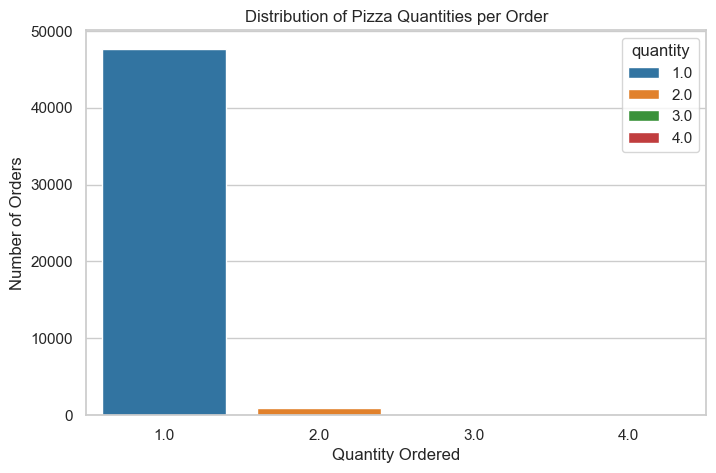

In [16]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df,
              x='quantity',
              hue='quantity',
              palette='tab10')
plt.title('Distribution of Pizza Quantities per Order')
plt.xlabel('Quantity Ordered')
plt.ylabel('Number of Orders')
plt.show();

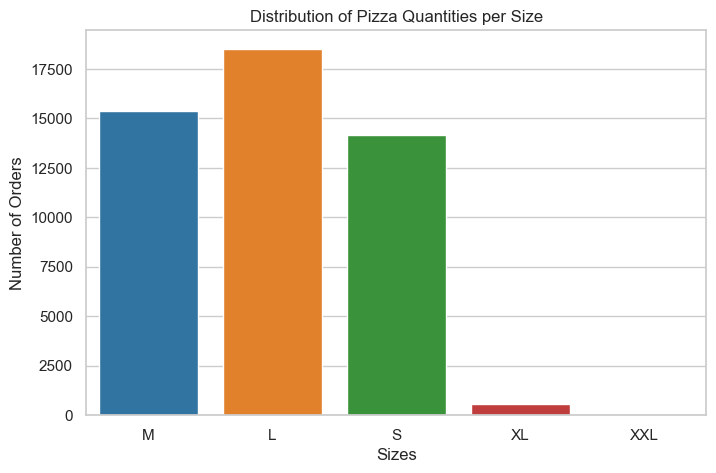

In [21]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df,
              x='pizza_size',
              hue='pizza_size',
              palette='tab10')
plt.title('Distribution of Pizza Quantities per Size')
plt.xlabel('Sizes')
plt.ylabel('Number of Orders')
plt.show();

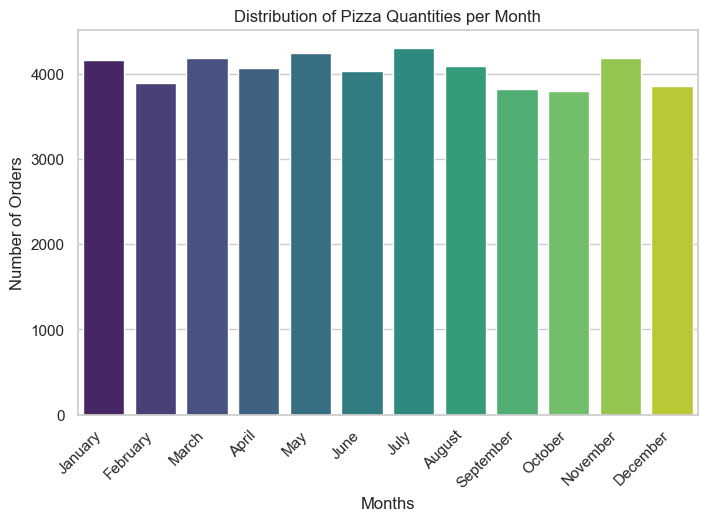

In [20]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df,
              x='month',
              hue='month',
              palette='viridis')
plt.title('Distribution of Pizza Quantities per Month')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Months')
plt.ylabel('Number of Orders')
plt.show();

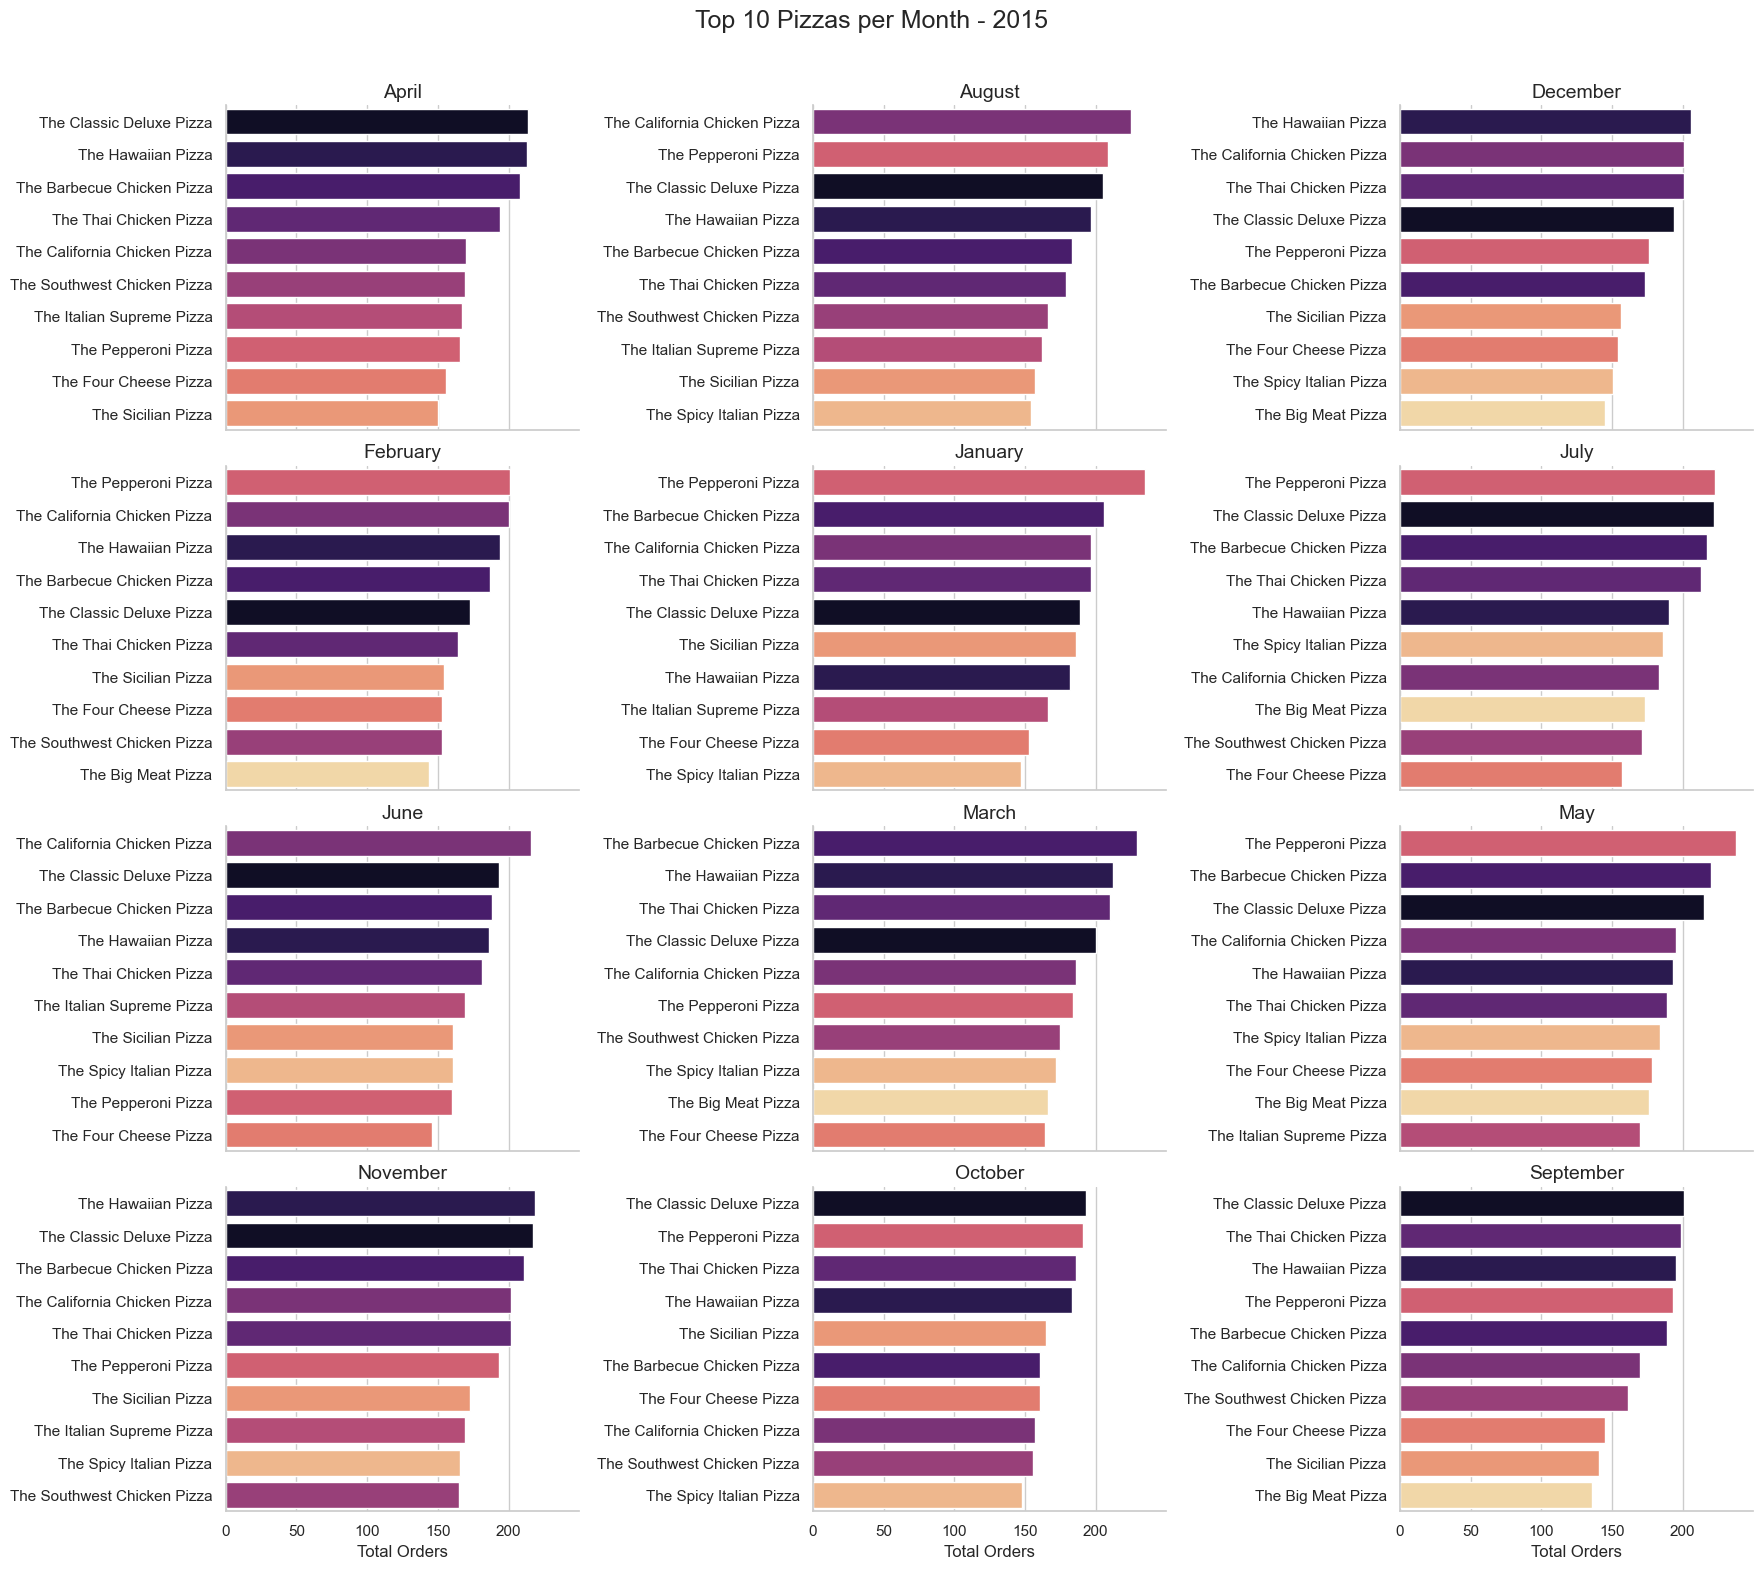

In [29]:
df_counts = df.groupby(['month', 'pizza_name']).size().reset_index(name='orders_count')
df_top10_monthly = df_counts.sort_values(['month', 'orders_count'], ascending=[True, False]).groupby('month').head(10)

g = sns.catplot(
    data=df_top10_monthly,
    x="orders_count",
    y="pizza_name",
    col="month",           
    kind="bar",           
    col_wrap=3,           
    sharey=False,         
    height=4,
    aspect=1.5,
    palette="magma",
    hue="pizza_name",      
    legend=False)

g.set_titles("{col_name}", size=14)
g.set_axis_labels("Total Orders", "")
plt.subplots_adjust(top=0.92) 
g.fig.suptitle('Top 10 Pizzas per Month - 2015', fontsize=18)
plt.show();

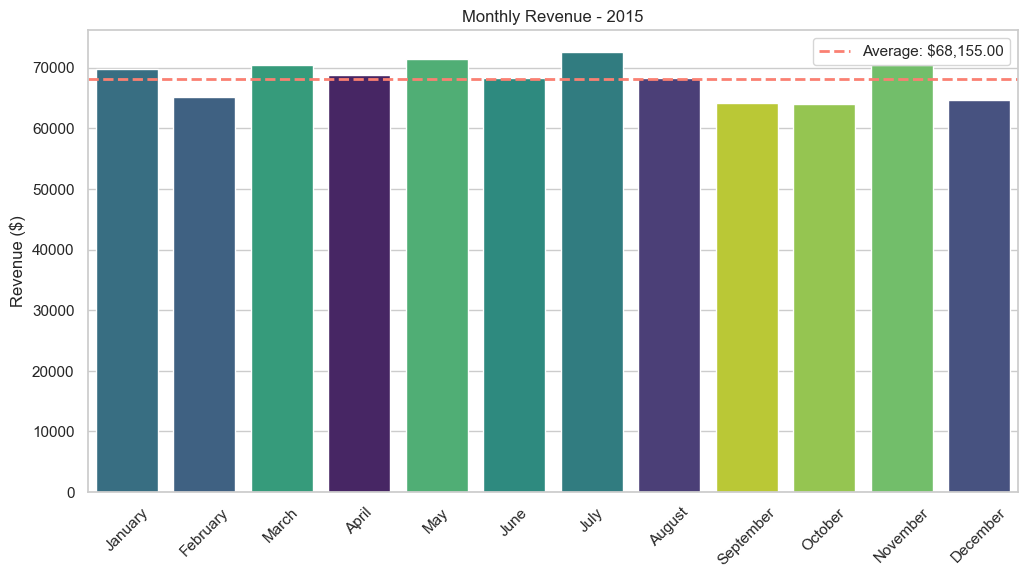

In [37]:
monthly_revenue = df.groupby('month')['total_price'].sum().reset_index()
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
average_revenue = monthly_revenue['total_price'].mean()

plt.figure(figsize=(12, 6))
sns.barplot(
    data=monthly_revenue, 
    x='month', 
    y='total_price', 
    order=month_order, 
    palette='viridis', 
    hue='month', 
    legend=False)

plt.axhline(average_revenue, color='salmon', linestyle='--', linewidth=2, label=f'Average: ${average_revenue:,.2f}')
plt.title('Monthly Revenue - 2015')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.xlabel('')
plt.legend()
plt.show();


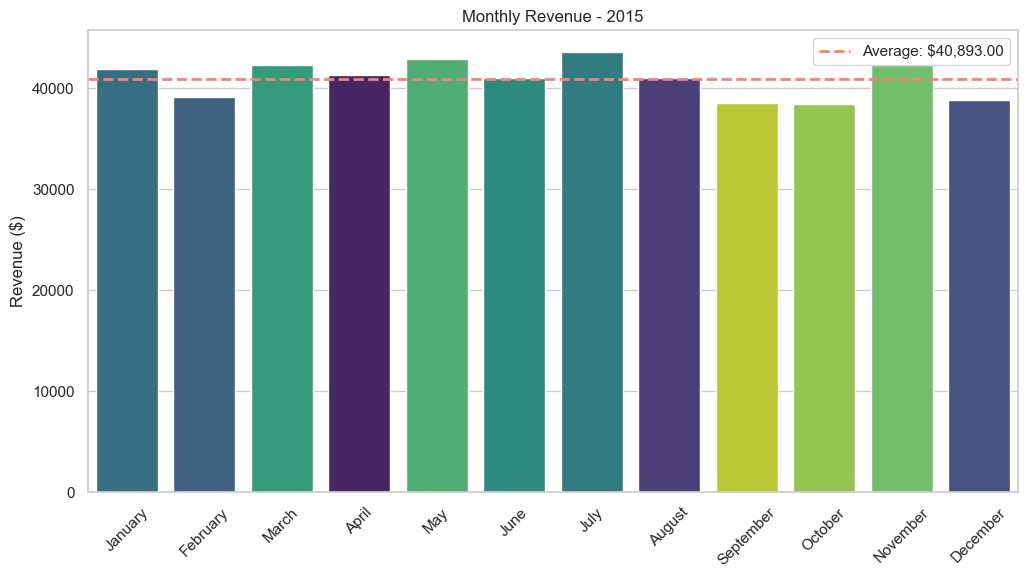

In [41]:
monthly_estimated_profit = df.groupby('month')['estimated_profit'].sum().reset_index()
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
average_estimated_profit = monthly_estimated_profit['estimated_profit'].mean()

plt.figure(figsize=(12, 6))
sns.barplot(
    data=monthly_estimated_profit, 
    x='month', 
    y='estimated_profit', 
    order=month_order, 
    palette='viridis', 
    hue='month', 
    legend=False)

plt.axhline(average_estimated_profit, color='salmon', linestyle='--', linewidth=2, label=f'Average: ${average_estimated_profit:,.2f}')
plt.title('Monthly Revenue - 2015')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.xlabel('')
plt.legend()
plt.show();


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   quantity           48620 non-null  float64       
 1   order_date         48620 non-null  datetime64[ns]
 2   order_time         48620 non-null  object        
 3   unit_price         48620 non-null  float64       
 4   total_price        48620 non-null  float64       
 5   pizza_size         48620 non-null  object        
 6   pizza_category     48620 non-null  object        
 7   pizza_ingredients  48620 non-null  object        
 8   pizza_name         48620 non-null  object        
 9   month              48620 non-null  object        
 10  estimated_profit   48620 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(6)
memory usage: 4.1+ MB
